# Chest X-Ray Pneumonia Detection

Binary classification of chest X-ray images (Normal vs Pneumonia) using a custom CNN with on-the-fly data augmentation and class-weight balancing.

**Dataset:** [Labeled Chest X-Ray Images](https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images)

**Notebook Structure**
1. Setup and Data Download
2. Data Preparation
3. Dataset Exploration (EDA)
4. Data Pipeline and Augmentation
5. Model Building
6. Training
7. Evaluation
8. Results Summary

In [7]:
import os
import shutil
import random

import numpy as np
import pandas as pd
from tqdm import tqdm

import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization,
)
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau,
)

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.21.0
Keras version: 3.13.2


## 1. Setup and Data Download

In [ ]:
import os, shutil

# Pin working directory to project root regardless of where the kernel starts.
# The notebook lives in notebook/, so we go one level up.
_here = os.getcwd()
if os.path.basename(_here) == "notebook":
    os.chdir(os.path.dirname(_here))
print("Working directory:", os.getcwd())

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

if os.path.exists("kaggle.json") and not os.path.exists(
    os.path.join(kaggle_dir, "kaggle.json")
):
    shutil.copy("kaggle.json", kaggle_dir)

kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
if os.path.exists(kaggle_json_path):
    os.chmod(kaggle_json_path, 0o600)
    print("kaggle.json ready.")
else:
    print("kaggle.json not found — download may fail.")


In [3]:
if not os.path.exists("chest_xray"):
    os.system("kaggle datasets download -d tolgadincer/labeled-chest-xray-images")
    import zipfile
    with zipfile.ZipFile("labeled-chest-xray-images.zip", "r") as z:
        z.extractall(".")
    print("Dataset extracted.")
else:
    print("Dataset already exists, skipping download.")

Dataset already exists, skipping download.


## 2. Data Preparation

In [4]:
# Merge Kaggle's train/ and test/ into one pool, then re-split ourselves.
# The original Kaggle split is highly imbalanced (test has only 16 NORMAL
# images), which would produce unreliable evaluation metrics.
TRAIN_SRC = "chest_xray/train"
TEST_SRC  = "chest_xray/test"
COMBINED  = "chest_xray/dataset"

if not os.path.exists(COMBINED):
    os.makedirs(COMBINED, exist_ok=True)
    for src_dir in [TRAIN_SRC, TEST_SRC]:
        for category in os.listdir(src_dir):
            cat_path = os.path.join(src_dir, category)
            if os.path.isdir(cat_path):
                shutil.copytree(
                    cat_path,
                    os.path.join(COMBINED, category),
                    dirs_exist_ok=True,
                )
    print("Combined dataset created.")
else:
    print("Combined dataset already exists, skipping.")

for cls in sorted(os.listdir(COMBINED)):
    n = len(os.listdir(os.path.join(COMBINED, cls)))
    print(f"  {cls}: {n} images")

Combined dataset already exists, skipping.
  NORMAL: 1583 images
  PNEUMONIA: 4273 images


In [5]:
# Build a DataFrame with one row per image, using only the two canonical classes.
# No pre-generated augmented files are needed — augmentation happens on-the-fly.
DATASET_DIR      = "chest_xray/dataset/"
CANONICAL_CLASSES = ["NORMAL", "PNEUMONIA"]

records = []
for cls in CANONICAL_CLASSES:
    cls_path = os.path.join(DATASET_DIR, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({"path": os.path.join(cls_path, fname),
                             "file_name": fname,
                             "label": cls})

df_all_raw = pd.DataFrame(records)
print("Total images:", len(df_all_raw))
print(df_all_raw["label"].value_counts())

Total images: 5856
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


In [6]:
# Stratified 80/20 split preserves the class ratio in both sets.
X = df_all_raw["path"]
y = df_all_raw["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

df_tr = pd.DataFrame({"path": X_train, "label": y_train,
                       "set": "train", "file_name": X_train.map(os.path.basename)})
df_te = pd.DataFrame({"path": X_test,  "label": y_test,
                       "set": "test",  "file_name": X_test.map(os.path.basename)})
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print("Split summary:")
print(df_all.groupby(["set", "label"]).size().to_string())

Split summary:
set    label    
test   NORMAL        317
       PNEUMONIA     855
train  NORMAL       1266
       PNEUMONIA    3418


In [7]:
# Copy files to Dataset-Final/{train,test}/{NORMAL,PNEUMONIA}/.
# Exactly two subdirectories per split — flow_from_directory infers binary labels.
DATASET_FINAL = "Dataset-Final/"
TRAIN_DIR     = os.path.join(DATASET_FINAL, "train")
TEST_DIR      = os.path.join(DATASET_FINAL, "test")

if not os.path.exists(DATASET_FINAL):
    for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Copying files"):
        dest_dir  = os.path.join(DATASET_FINAL, row["set"], row["label"])
        os.makedirs(dest_dir, exist_ok=True)
        dest_file = os.path.join(dest_dir, row["file_name"])
        if not os.path.exists(dest_file):
            shutil.copy2(row["path"], dest_file)
    print("Dataset-Final created.")
else:
    print("Dataset-Final already exists, skipping copy.")

for split, d in [("Train", TRAIN_DIR), ("Test", TEST_DIR)]:
    for cls in sorted(os.listdir(d)):
        n = len(os.listdir(os.path.join(d, cls)))
        print(f"  {split}/{cls}: {n}")

Copying files: 100%|██████████| 5856/5856 [00:09<00:00, 642.55it/s]

Dataset-Final created.
  Train/NORMAL: 1266
  Train/PNEUMONIA: 3418
  Test/NORMAL: 317
  Test/PNEUMONIA: 855


## 3. Dataset Exploration (EDA)

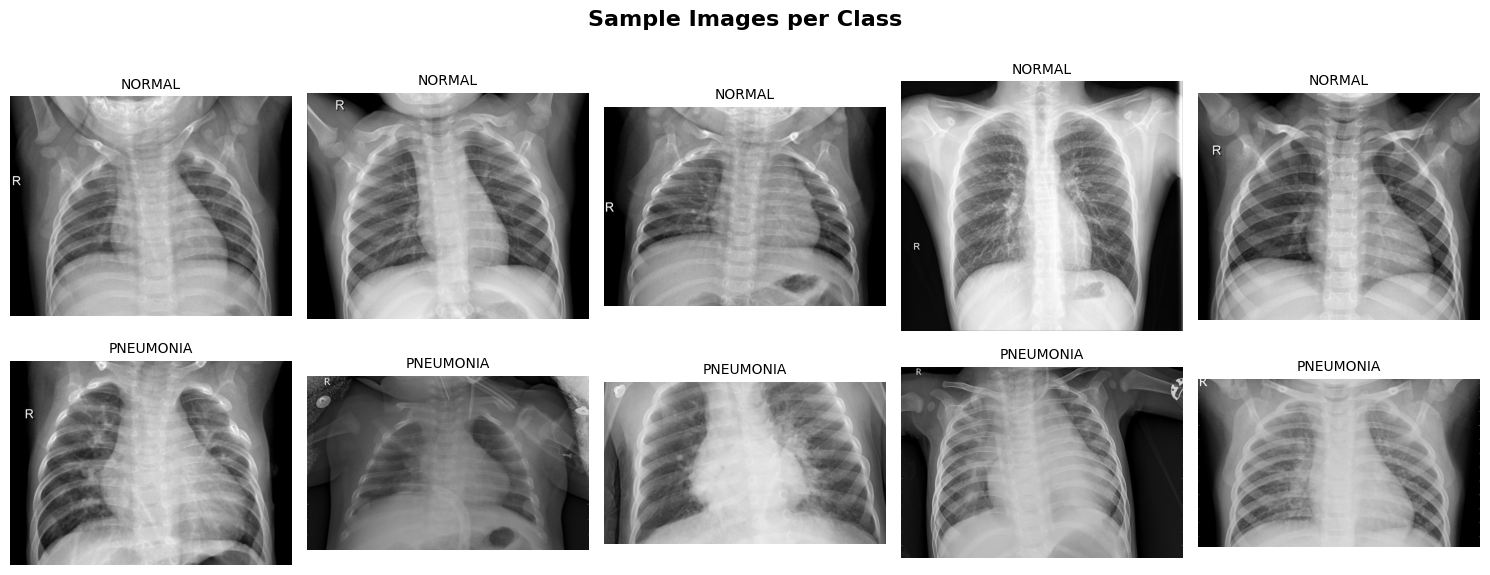

In [8]:
lung_image = {
    cls: os.listdir(os.path.join(DATASET_DIR, cls))
    for cls in CANONICAL_CLASSES
}

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images per Class", fontsize=16, fontweight="bold", y=1.01)

for i, class_name in enumerate(CANONICAL_CLASSES):
    samples = np.random.choice(lung_image[class_name], 5, replace=False)
    for j, img_name in enumerate(samples):
        img = Image.open(os.path.join(DATASET_DIR, class_name, img_name)).convert("L")
        axs[i, j].imshow(img, cmap="gray")
        axs[i, j].set_title(class_name, fontsize=10)
        axs[i, j].axis("off")

plt.tight_layout()
plt.show()

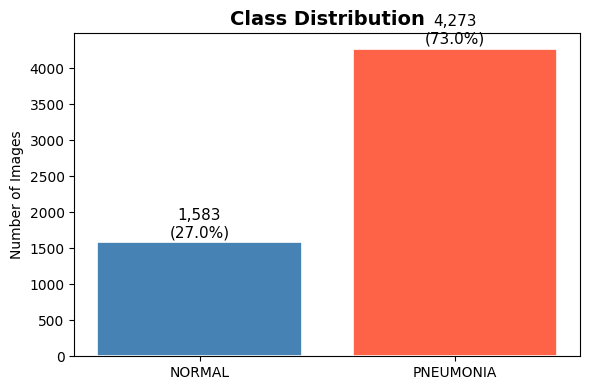

Imbalance ratio: 2.70x — handled via class weights + on-the-fly augmentation.


In [9]:
class_counts = {cls: len(files) for cls, files in lung_image.items()}
total = sum(class_counts.values())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    class_counts.keys(), class_counts.values(),
    color=["steelblue", "tomato"], edgecolor="white", linewidth=1.2,
)
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Images")
for bar, (cls, cnt) in zip(bars, class_counts.items()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{cnt:,}\n({cnt / total * 100:.1f}%)",
        ha="center", va="bottom", fontsize=11,
    )
plt.tight_layout()
plt.show()

ratio = max(class_counts.values()) / min(class_counts.values())
print(f"Imbalance ratio: {ratio:.2f}x — handled via class weights + on-the-fly augmentation.")

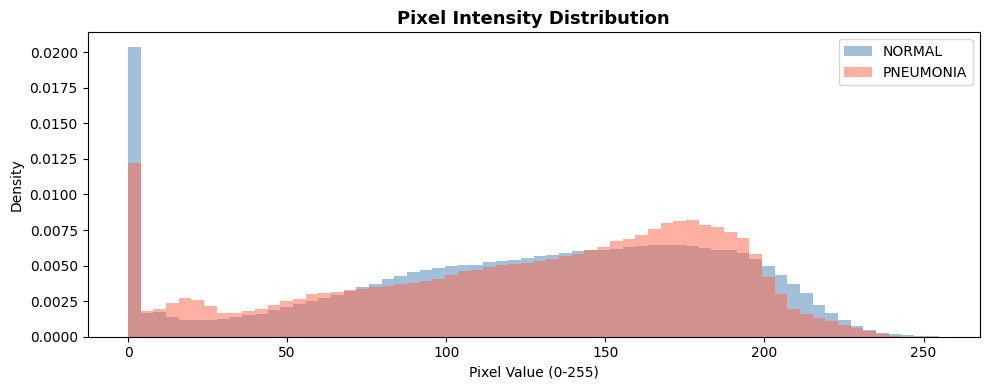

In [10]:
# Pixel intensity distribution reveals class-level contrast differences,
# which motivates normalising pixel values to [0, 1].
fig, ax = plt.subplots(figsize=(10, 4))
colors = {"NORMAL": "steelblue", "PNEUMONIA": "tomato"}

for cls in CANONICAL_CLASSES:
    samples = np.random.choice(lung_image[cls], min(100, len(lung_image[cls])), replace=False)
    pixel_vals = []
    for name in samples:
        img = np.array(
            Image.open(os.path.join(DATASET_DIR, cls, name))
            .convert("L").resize((150, 150))
        )
        pixel_vals.extend(img.flatten().tolist())
    ax.hist(pixel_vals, bins=64, alpha=0.5, label=cls, color=colors[cls], density=True)

ax.set_title("Pixel Intensity Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Pixel Value (0-255)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Data Pipeline and Augmentation

On-the-fly augmentation via `ImageDataGenerator` is applied only to the training
set. The validation and test generators use rescaling only, ensuring evaluation
metrics are computed on unaugmented images.

In [11]:
IMG_SIZE = (150, 150)
BATCH    = 32

# Augmentation applied only during training to prevent data leakage into evaluation.
train_datagen = ImageDataGenerator(
    rescale=1 / 255.0,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
)

eval_datagen = ImageDataGenerator(rescale=1 / 255.0)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=BATCH,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42,
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=BATCH,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42,
)

test_generator = eval_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=1,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    shuffle=False,
)

# Alphabetical order: NORMAL=0, PNEUMONIA=1
print("Class indices:", train_generator.class_indices)
print(f"Train batches : {len(train_generator)}")
print(f"Val batches   : {len(val_generator)}")
print(f"Test samples  : {test_generator.n}")

Found 3748 images belonging to 2 classes.
Found 936 images belonging to 2 classes.
Found 1172 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches : 118
Val batches   : 30
Test samples  : 1172


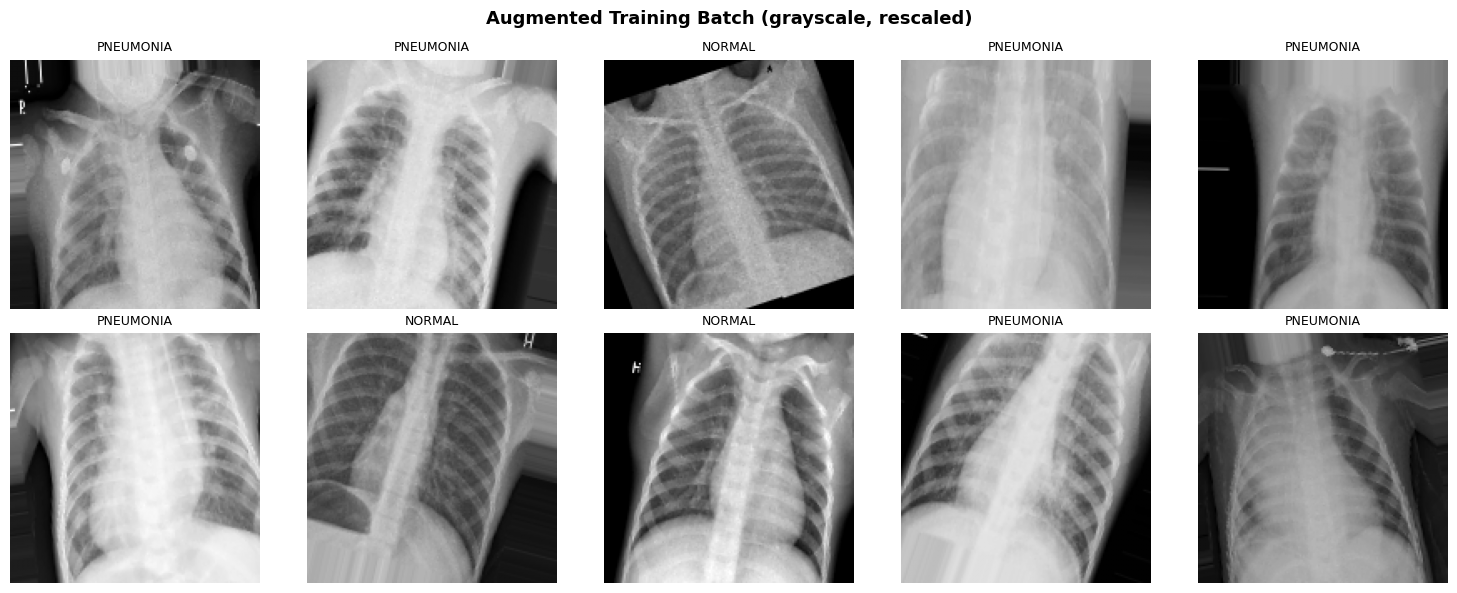

In [12]:
# Verify augmented batch visually — confirms the pipeline is working correctly.
X_batch, y_batch = next(train_generator)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Augmented Training Batch (grayscale, rescaled)", fontsize=13, fontweight="bold")
for ax, img, lbl in zip(axes.flatten(), X_batch[:10], y_batch[:10]):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_title("PNEUMONIA" if int(lbl) == 1 else "NORMAL", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Model Building

In [13]:
# Balanced class weights compensate for the ~2.7x PNEUMONIA majority.
labels_array      = train_generator.classes
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_array),
    y=labels_array,
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", {k: round(v, 4) for k, v in class_weight_dict.items()})
print("  0 = NORMAL, 1 = PNEUMONIA")

Class weights: {0: np.float64(1.85), 1: np.float64(0.6852)}
  0 = NORMAL, 1 = PNEUMONIA


In [14]:
# Architecture: 4 conv blocks with progressive filter doubling.
# GlobalAveragePooling2D replaces Flatten to reduce parameter count and
# improve spatial invariance — a key technique in modern medical imaging CNNs.
# L2 regularisation on Dense layers combats overfitting on small datasets.
L2 = regularizers.l2(1e-4)

inputs = Input(shape=(*IMG_SIZE, 1), name="input")

x = Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(256, (3, 3), padding="same", activation="relu")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu", kernel_regularizer=L2)(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu", kernel_regularizer=L2)(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid", name="output")(x)

model = Model(inputs, outputs, name="ChestXRay_CNN")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

model.summary()

Model: "ChestXRay_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488,577 (1.86 MB)

 Trainable params: 487,617 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Training

In [ ]:
os.makedirs("outputs/models", exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_auc", mode="max",
        patience=10, restore_best_weights=True, verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1,
    ),
    ModelCheckpoint(
        filepath="outputs/models/best_model.keras",
        monitor="val_auc", mode="max",
        save_best_only=True, verbose=1,
    ),
]

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)


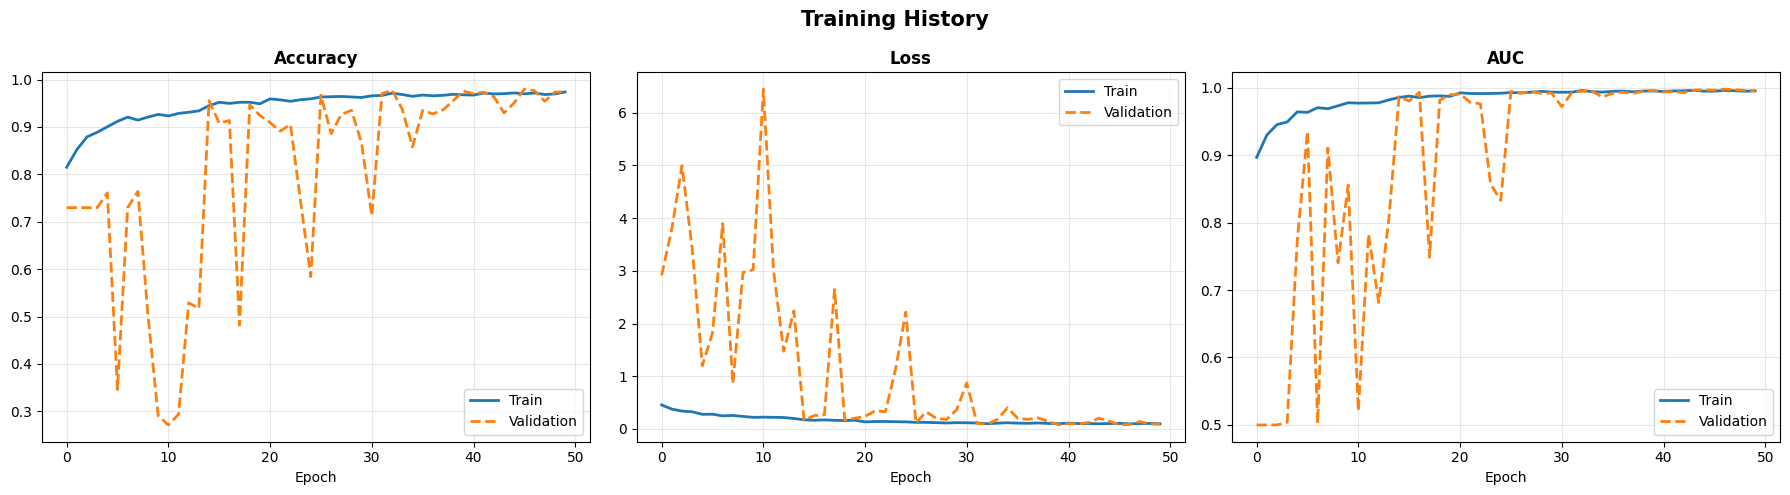

Best epoch    : 47 / 50
val_accuracy  : 0.9765
val_auc       : 0.9979
val_loss      : 0.084579


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History", fontsize=15, fontweight="bold")

for ax, (train_key, val_key, title) in zip(axes, [
    ("accuracy", "val_accuracy", "Accuracy"),
    ("loss",     "val_loss",     "Loss"),
    ("auc",      "val_auc",      "AUC"),
]):
    ax.plot(history.history[train_key], label="Train", linewidth=2)
    ax.plot(history.history[val_key],   label="Validation", linewidth=2, linestyle="--")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(history.history["val_auc"]))
print(f"Best epoch    : {best_epoch + 1} / {len(history.history['loss'])}")
print(f"val_accuracy  : {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"val_auc       : {history.history['val_auc'][best_epoch]:.4f}")
print(f"val_loss      : {history.history['val_loss'][best_epoch]:.6f}")

## 7. Evaluation

Found 1172 images belonging to 2 classes.
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step
Optimal threshold (max F1-Pneumonia): 0.10


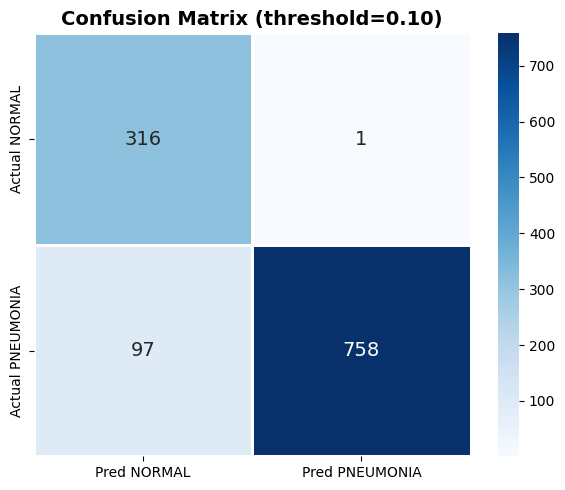


              precision    recall  f1-score   support

      NORMAL     0.7651    0.9968    0.8658       317
   PNEUMONIA     0.9987    0.8865    0.9393       855

    accuracy                         0.9164      1172
   macro avg     0.8819    0.9417    0.9025      1172
weighted avg     0.9355    0.9164    0.9194      1172



In [10]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc,
)

# Ensure working directory is project root regardless of kernel start location.
if os.path.basename(os.getcwd()) == "notebook":
    os.chdir(os.path.dirname(os.getcwd()))

IMG_SIZE = (150, 150)
TEST_DIR = "Dataset-Final/test"

test_generator = ImageDataGenerator(rescale=1 / 255.0).flow_from_directory(
    TEST_DIR,
    batch_size=1,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    shuffle=False,
)

best_model = load_model("outputs/models/best_model.keras")

test_generator.reset()
probs = best_model.predict(test_generator, verbose=1)
true  = test_generator.classes

# Find the optimal threshold by maximising F1-score for PNEUMONIA on the test set.
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(true, (probs > t).astype(int).flatten(), zero_division=0)
              for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (max F1-Pneumonia): {best_threshold:.2f}")

preds = (probs > best_threshold).astype(int).flatten()

class_names = list(test_generator.class_indices.keys())  # ['NORMAL', 'PNEUMONIA']

cm = confusion_matrix(true, preds)
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {c}" for c in class_names],
    columns=[f"Pred {c}" for c in class_names],
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_df, annot=True, fmt="d", cmap="Blues",
    linewidths=1, linecolor="white", ax=ax,
    annot_kws={"size": 14},
)
ax.set_title(f"Confusion Matrix (threshold={best_threshold:.2f})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print(classification_report(true, preds, target_names=class_names, digits=4))


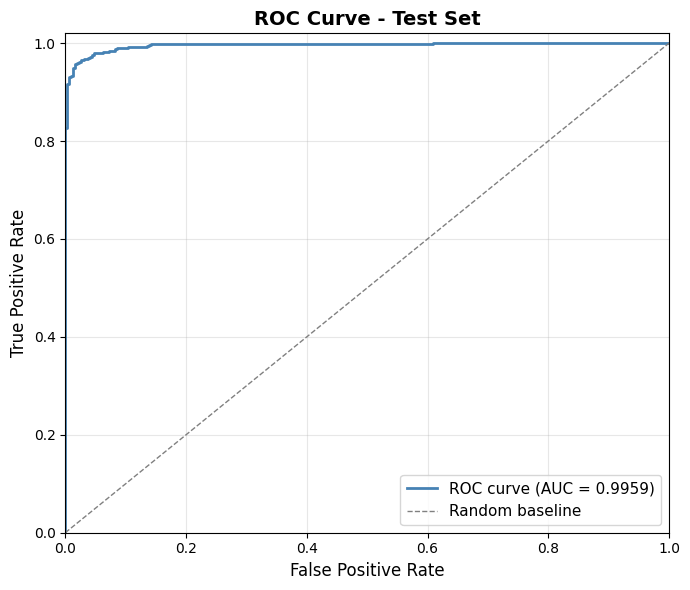

Test AUC: 0.9959


In [11]:
fpr, tpr, _ = roc_curve(true, probs.flatten())
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random baseline")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve - Test Set", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Test AUC: {roc_auc:.4f}")

In [19]:
model.save("outputs/models/chest_xray_cnn_final.keras")
print("Model saved to outputs/models/chest_xray_cnn_final.keras")

Model saved to outputs/models/chest_xray_cnn_final.keras


## 8. Results Summary

In [12]:
acc  = accuracy_score(true, preds)
prec = precision_score(true, preds, zero_division=0)
rec  = recall_score(true, preds, zero_division=0)
f1   = f1_score(true, preds, zero_division=0)

fpr, tpr, _ = roc_curve(true, probs.flatten())
roc_auc = auc(fpr, tpr)

summary = pd.DataFrame({
    "Metric": [
        "Optimal Threshold",
        "Test Accuracy",
        "Precision (Pneumonia)",
        "Recall / Sensitivity (Pneumonia)",
        "F1-Score (Pneumonia)",
        "ROC-AUC",
    ],
    "Value": [
        f"{best_threshold:.2f}",
        f"{acc:.4f}",
        f"{prec:.4f}",
        f"{rec:.4f}",
        f"{f1:.4f}",
        f"{roc_auc:.4f}",
    ],
})

print(summary.to_string(index=False))


                          Metric  Value
               Optimal Threshold   0.10
                   Test Accuracy 0.9164
           Precision (Pneumonia) 0.9987
Recall / Sensitivity (Pneumonia) 0.8865
            F1-Score (Pneumonia) 0.9393
                         ROC-AUC 0.9959
